In [2]:
import yfinance as yf
import pandas as pd

etfs = ["SCHD", "QQQ", "JEPQ"]

price_data = {}
div_data = {}

for etf in etfs:
    ticker = yf.Ticker(etf)
    
    df = ticker.history(start="2020-01-01")
    if df.empty:
        continue

    price_data[etf] = df["Close"]

    div = ticker.dividends
    div_data[etf] = div

price_df = pd.DataFrame(price_data)

# Daily returns
returns_df = price_df.pct_change().dropna()

returns_df.head()

# Cumulative returns
cumulative_returns = (1 + returns_df).cumprod()

cumulative_returns.head()

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

monthly_returns = price_df.resample('ME').ffill().pct_change()

monthly_returns.head()

monthly_returns['Year'] = monthly_returns.index.year
monthly_returns['Month'] = monthly_returns.index.month

pivot_qqq = monthly_returns.pivot_table(
    values='QQQ',
    index='Year',
    columns='Month'
)
pivot_schd = monthly_returns.pivot_table(
    values='SCHD',
    index='Year',
    columns='Month'
)
pivot_jepq = monthly_returns.pivot_table(
    values='JEPQ',
    index='Year',
    columns='Month'
)

import seaborn as sns
import matplotlib.pyplot as plt

## 📌 Total Return Analysis (Dividend Included)

In this step, ETF performance is analyzed by incorporating dividends into returns.

Unlike price-based analysis, total return reflects both capital appreciation and income generated from dividends.

---

## ❗ Why Total Return Matters

Price return alone may underestimate the performance of income-focused ETFs.

Dividend-paying ETFs such as SCHD and JEPQ generate additional income, which contributes to overall returns.

---

## 🎯 Objective

The goal of this step is to:

- Calculate total returns by combining price returns and dividend yield  
- Compare ETF performance when dividend income is included  
- Evaluate how dividends impact overall investment performance  

---

## ⚙️ Methodology

Total return is approximated as:

Total Return = Price Return + Dividend Yield

Where:

- Price Return is calculated using percentage change in closing prices  
- Dividend Yield is calculated as dividend amount divided by price  

---

## ⚠️ Limitation

Dividend returns are approximated by adding dividend yield to price returns.

This approach does not reflect exact reinvestment behavior and serves as a simplified estimation.

---

## 📊 Expected Insight

This analysis aims to show how including dividend income changes the perspective of ETF performance compared to price-only analysis.

## 🧠 Implementation Overview

In this step, total return is calculated by combining price returns and dividend yield. 

In [3]:
# Total Return (Dividend Included)

total_return_df = pd.DataFrame()

for etf in etfs:
    price = price_df[etf]

    # Dividend data
    div = div_data[etf]
    div = div.reindex(price.index, fill_value=0)

    # Dividend yield
    dividend_yield = div / price

    # Price return
    price_return = price.pct_change()

    # Total return (price + dividend)
    total_return = price_return + dividend_yield

    total_return_df[etf] = total_return

# Cumulative total return
cumulative_total_return = (1 + total_return_df).cumprod()

cumulative_total_return.head()

,SCHD,QQQ,JEPQ
Date,,,
2020-01-02 00:00:00-05:00,NaN,NaN,NaN
2020-01-03 00:00:00-05:00,0.992767,0.990840,NaN
2020-01-06 00:00:00-05:00,0.992595,0.997224,NaN
2020-01-07 00:00:00-05:00,0.991217,0.997085,NaN
2020-01-08 00:00:00-05:00,0.995006,1.004580,NaN


## 📊 Total Return Visualization

In this step, cumulative total returns are visualized for each ETF.

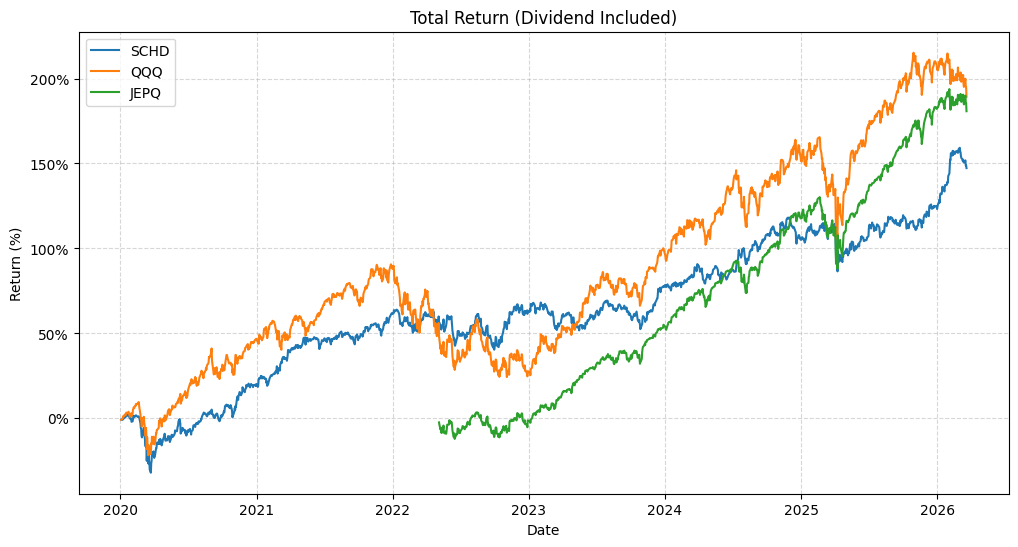

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.figure(figsize=(12,6))

for etf in cumulative_total_return.columns:
    plt.plot(
        cumulative_total_return.index,
        cumulative_total_return[etf] - 1,
        label=etf
    )

plt.title("Total Return (Dividend Included)")
plt.xlabel("Date")
plt.ylabel("Return (%)")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("images/total_return.png")
plt.show()

## 🔍 Result & Interpretation

The total return analysis reveals several key insights when dividends are included.

First, QQQ still shows the strongest overall growth among the ETFs.  
This indicates that price appreciation remains the dominant driver of long-term returns for growth-focused strategies.

Second, SCHD demonstrates steady and consistent growth.  
While its price return is lower than QQQ, the inclusion of dividends improves its overall performance and reduces the performance gap.

Third, JEPQ shows a meaningful improvement when dividends are considered.  
Although its price growth alone appears weaker, dividend income contributes significantly to its total return, especially over time.

Overall, the results suggest that price-based analysis alone is not sufficient to fully evaluate ETF performance.  
Including dividends provides a more comprehensive view of investment outcomes.

At the same time, growth-oriented ETFs like QQQ tend to outperform during strong market uptrends,  
while dividend-focused ETFs offer additional return through income and may provide relatively more stable performance during market downturns.